# K邻近回归即使用目标点附近加权平均方式的非参数化回归

D:\pycharm jupyter git\.venv\Lib\site-packages\sklearn\datasets\_base.py:1518: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


下载数据集失败: HTTP Error 403: Forbidden
尝试使用其他方法加载数据集...
已使用随机生成的演示数据
数据集维度： (1000, 9)
数据集特征：
 Index(['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'target'],
      dtype='object')
最优邻居数 k = 6
最佳均方误差 (MSE) = 5794.240398575971
测试集均方误差 (MSE) = 5791.313369519492
测试集 R2 score = 0.8037020118775793


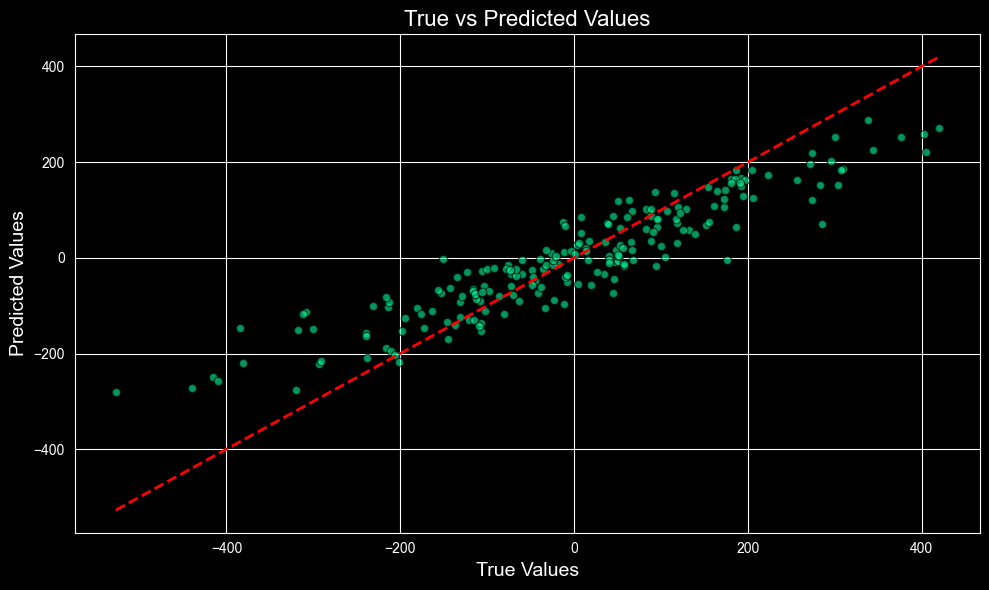

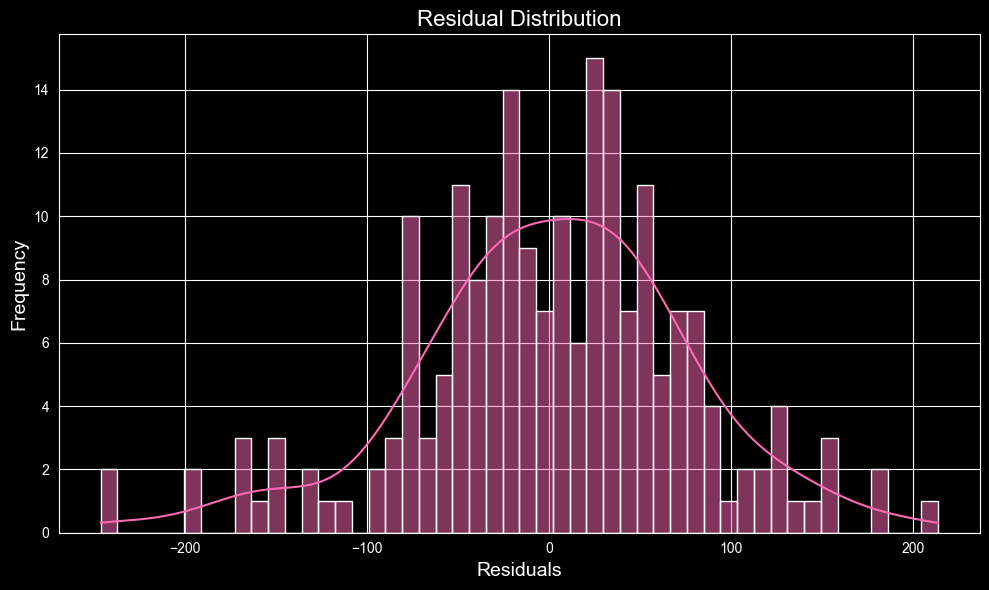

AttributeError: 'Series' object has no attribute 'data'

<Figure size 1200x600 with 0 Axes>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import ssl

# 为了解决HTTPS问题
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# 加载 California 房价数据集
try:
    housing = fetch_california_housing(as_frame=True)
    data = housing.frame
except Exception as e:
    print(f"下载数据集失败: {e}")
    print("尝试使用其他方法加载数据集...")
    # 如果无法下载，则使用随机数据演示
    from sklearn.datasets import make_regression
    X, y = make_regression(n_samples=1000, n_features=8, noise=10, random_state=42)
    data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
    data['target'] = y
    print("已使用随机生成的演示数据")

# 打印数据基本信息
print("数据集维度：", data.shape)
print("数据集特征：\n", data.columns)

# 选择特征与目标变量
if 'target' in data.columns:
    X = data.drop("target", axis=1)  # 使用随机生成的数据
    y = data["target"]
else:
    X = data.drop("MedHouseVal", axis=1)  # 房屋中位数作为目标变量
    y = data["MedHouseVal"]

# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 初始化 KNN 回归器
knn = KNeighborsRegressor()

# 设置超参数搜索空间：邻居数从 1 到 30
param_grid = {'n_neighbors': np.arange(1, 31)}

# 使用 GridSearchCV 进行超参数优化，采用 5 折交叉验证
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 输出最优参数与对应的得分
best_k = grid_search.best_params_['n_neighbors']
best_score = -grid_search.best_score_
print("最优邻居数 k =", best_k)
print("最佳均方误差 (MSE) =", best_score)

# 使用最优参数训练模型
best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = best_knn.predict(X_test)

# 计算测试集上的 MSE 和 R2 分数
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("测试集均方误差 (MSE) =", mse)
print("测试集 R2 score =", r2)

# 可视化：真实值 vs 预测值
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='mediumspringgreen', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True Values", fontsize=14)
plt.ylabel("Predicted Values", fontsize=14)
plt.title("True vs Predicted Values", fontsize=16)
plt.tight_layout()
plt.show()

# 可视化：残差分布
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, color='hotpink')
plt.xlabel("Residuals", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Residual Distribution", fontsize=16)
plt.tight_layout()
plt.show()

# 可视化：GridSearchCV 中不同 k 值的均方误差热力图
# 提取所有搜索结果
results = pd.DataFrame(grid_search.cv_results_)
results['mean_test_mse'] = -results['mean_test_score']

plt.figure(figsize=(12, 6))
plt.plot(results['param_n_neighbors'].data, results['mean_test_mse'], marker='o', linestyle='-', color='dodgerblue')
plt.xlabel("Number of Neighbors (k)", fontsize=14)
plt.ylabel("Mean Squared Error (MSE)", fontsize=14)
plt.title("Grid Search MSE vs k", fontsize=16)
plt.xticks(results['param_n_neighbors'].data)
plt.grid(True)
plt.tight_layout()
plt.show()

# 添加额外的可视化：不同距离权重方法的比较
weights = ['uniform', 'distance']
plt.figure(figsize=(12, 6))
for weight in weights:
    knn_weight = KNeighborsRegressor(n_neighbors=best_k, weights=weight)
    knn_weight.fit(X_train, y_train)
    y_pred_weight = knn_weight.predict(X_test)
    mse_weight = mean_squared_error(y_test, y_pred_weight)
    r2_weight = r2_score(y_test, y_pred_weight)
    print(f"{weight} 权重方法 - MSE: {mse_weight:.4f}, R2: {r2_weight:.4f}")
    
    plt.scatter(y_test, y_pred_weight, alpha=0.6, label=f'{weight} weights', s=30)
    
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("True Values", fontsize=14)
plt.ylabel("Predicted Values", fontsize=14)
plt.title("Comparison of Different Weight Methods", fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()